
# Detecção de Fraudes em Transações de Cartão de Crédito

Projeto de Machine Learning para identificar transações fraudulentas em uma base altamente desbalanceada.

**Dataset:** `https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv`

## Objetivos
- Explorar o desbalanceamento das classes;
- Preparar os dados;
- Treinar Regressão Logística, Random Forest e XGBoost;
- Comparar Precision, Recall, F1 e ROC-AUC;
- Avaliar curvas ROC e Precision-Recall;
- Testar diferentes limiares de decisão;
- Comparar undersampling e oversampling;
- Utilizar SHAP para explicar as decisões do modelo.

> O dataset é baixado diretamente pela URL durante a execução e não deve ser colocado no repositório.


In [1]:

# Instalação das dependências
# No Google Colab, descomente a linha abaixo se necessário.

!pip -q install xgboost shap imbalanced-learn


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier

import shap

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"


## 1. Carregamento dos dados

In [3]:

df = pd.read_csv(DATASET_URL)

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
df.head()


Linhas: 284,807
Colunas: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:

print("Informações da base:")
df.info()

print("\nValores ausentes:")
print(df.isnull().sum().sum())

print("\nResumo estatístico:")
df.describe().T


Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2. Entendendo o desbalanceamento

In [ ]:

class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

distribution = pd.DataFrame({
    "Quantidade": class_counts,
    "Percentual (%)": class_percent
})

distribution.index = ["Normal (0)", "Fraude (1)"]
distribution


,Quantidade,Percentual (%)
Normal (0),284315,99.827251
Fraude (1),492,0.172749


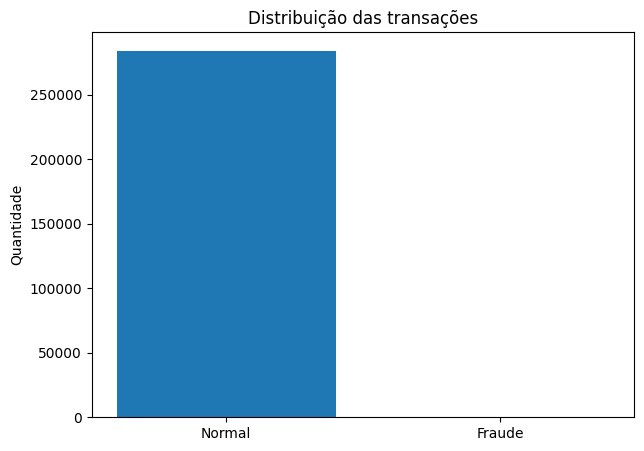

Somente 0.173% das transações são fraudes. Por isso, acurácia sozinha não é uma boa métrica.


In [ ]:

plt.figure(figsize=(7, 5))
plt.bar(["Normal", "Fraude"], class_counts.values)
plt.title("Distribuição das transações")
plt.ylabel("Quantidade")
plt.show()

print(
    f"Somente {class_percent.loc[1]:.3f}% das transações são fraudes. "
    "Por isso, acurácia sozinha não é uma boa métrica."
)


## 3. Preparação dos dados

In [ ]:

# Criamos uma variável com o logaritmo do valor da transação.
# log1p evita problemas quando Amount é zero.
df["LogAmount"] = np.log1p(df["Amount"])

features = [col for col in df.columns if col not in ["Class", "Amount"]]
X = df[features]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nProporção de fraude:")
print(f"Treino: {y_train.mean()*100:.3f}%")
print(f"Teste:  {y_test.mean()*100:.3f}%")


Treino: (227845, 30)
Teste: (56962, 30)

Proporção de fraude:
Treino: 0.173%
Teste:  0.172%


## 4. Modelos

In [ ]:

# O peso da classe positiva é calculado a partir do conjunto de treino.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Treinando: {name}")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nTodos os modelos foram treinados.")


Treinando: Regressão Logística
Treinando: Random Forest
Treinando: XGBoost

Todos os modelos foram treinados.


## 5. Avaliação dos modelos

In [ ]:

def evaluate_models(models, X_test, y_test, threshold=0.5):
    rows = []

    for name, model in models.items():
        probabilities = model.predict_proba(X_test)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        rows.append({
            "Modelo": name,
            "Precision fraude": precision_score(y_test, predictions, zero_division=0),
            "Recall fraude": recall_score(y_test, predictions, zero_division=0),
            "F1 fraude": f1_score(y_test, predictions, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, probabilities),
            "Average Precision": average_precision_score(y_test, probabilities)
        })

    return pd.DataFrame(rows).sort_values("Recall fraude", ascending=False)

results = evaluate_models(trained_models, X_test, y_test)
results


,Modelo,Precision fraude,Recall fraude,F1 fraude,ROC-AUC,Average Precision
0,Regressão Logística,0.060281,0.918367,0.113136,0.971117,0.711314
2,XGBoost,0.863158,0.836735,0.849741,0.979763,0.876461
1,Random Forest,0.961039,0.755102,0.845714,0.947063,0.859065


In [ ]:

for name, model in trained_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Normal", "Fraude"],
        digits=4,
        zero_division=0
    ))


Regressão Logística
              precision    recall  f1-score   support

      Normal     0.9999    0.9753    0.9874     56864
      Fraude     0.0603    0.9184    0.1131        98

    accuracy                         0.9752     56962
   macro avg     0.5301    0.9468    0.5503     56962
weighted avg     0.9982    0.9752    0.9859     56962

Random Forest
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9998     56864
      Fraude     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

XGBoost
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9997     56864
      Fraude     0.8632    0.8367    0.8497        98

    accuracy                         0.9995     56962
   macro avg     0.9314    0.9183    0.9247     56962
weighted avg     0.9995    0.999

## 6. Matrizes de confusão

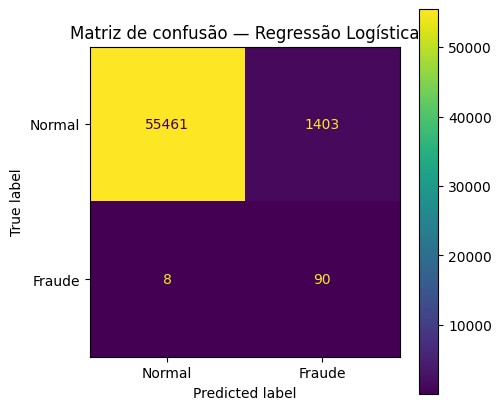

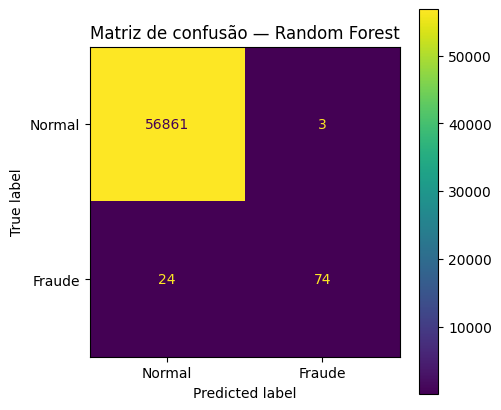

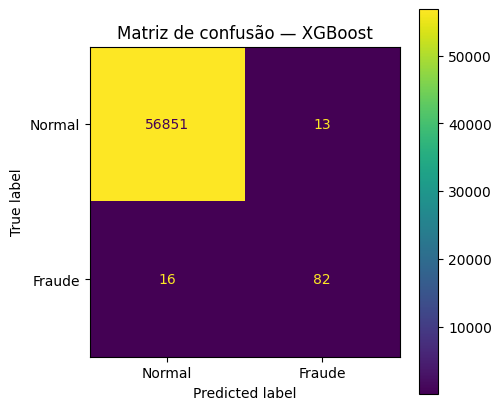

In [ ]:

for name, model in trained_models.items():
    predictions = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Fraude"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax)
    ax.set_title(f"Matriz de confusão — {name}")
    plt.show()


## 7. Curva ROC

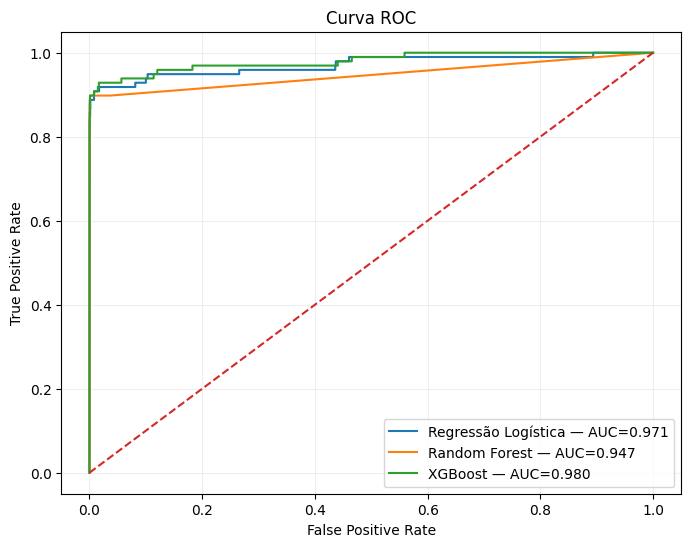

In [ ]:

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name} — AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 8. Curva Precision-Recall

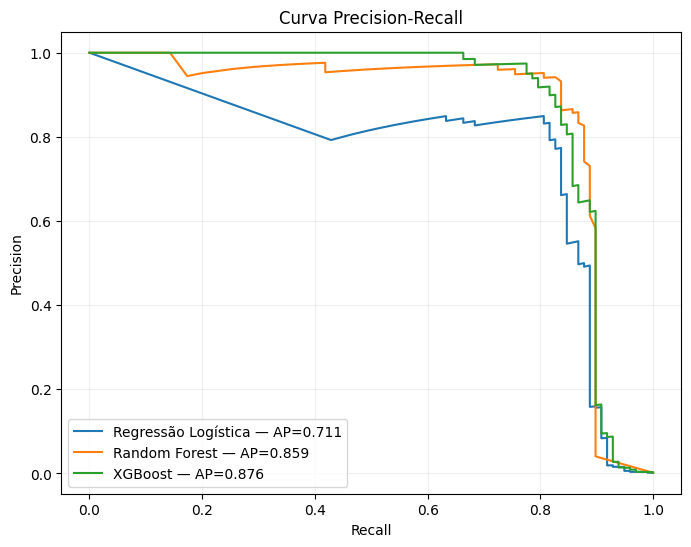

In [ ]:

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap = average_precision_score(y_test, probabilities)
    plt.plot(recall, precision, label=f"{name} — AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 9. Ajuste do limiar de decisão

In [ ]:

# Vamos usar o XGBoost para demonstrar o efeito do threshold.
threshold_model_name = "XGBoost"
threshold_model = trained_models[threshold_model_name]
probabilities = threshold_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)
threshold_rows = []

for threshold in thresholds:
    predictions = (probabilities >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results


,Threshold,Precision,Recall,F1
0,0.05,0.606897,0.897959,0.724280
1,0.10,0.705882,0.857143,0.774194
2,0.15,0.792453,0.857143,0.823529
3,0.20,0.807692,0.857143,0.831683
4,0.25,0.813725,0.846939,0.830000
5,0.30,0.828283,0.836735,0.832487
6,0.35,0.836735,0.836735,0.836735
7,0.40,0.854167,0.836735,0.845361
8,0.45,0.863158,0.836735,0.849741
9,0.50,0.863158,0.836735,0.849741


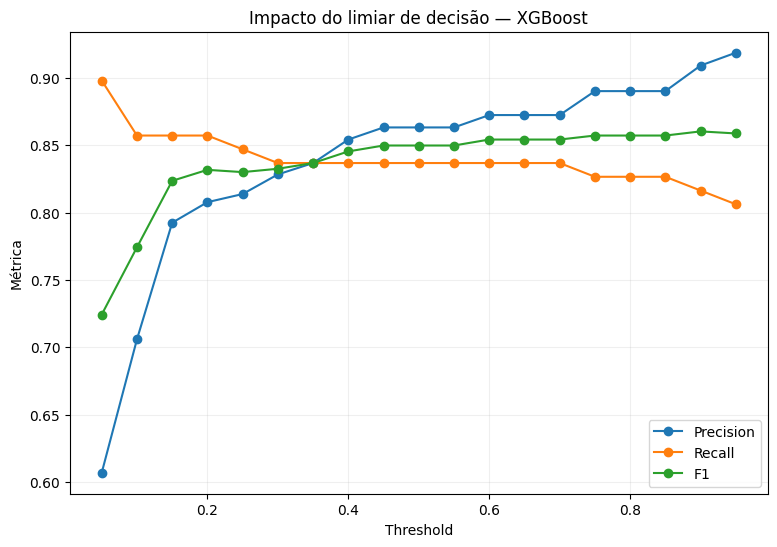

In [ ]:

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Impacto do limiar de decisão — XGBoost")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



### Escolha do threshold

Não existe um threshold universalmente correto para fraude. A escolha depende do equilíbrio desejado entre encontrar fraudes e evitar falsos positivos.

A tabela acima permite observar esse trade-off. Para este projeto, podemos selecionar o threshold que apresenta o maior F1 entre os valores testados, como uma regra objetiva para o exemplo.


In [ ]:

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print(f"Threshold selecionado pelo maior F1: {best_threshold:.2f}")
display(best_threshold_row.to_frame().T)


Threshold selecionado pelo maior F1: 0.90


,Threshold,Precision,Recall,F1
17,0.9,0.909091,0.816327,0.860215


In [ ]:

final_predictions = (probabilities >= best_threshold).astype(int)

print(classification_report(
    y_test,
    final_predictions,
    target_names=["Normal", "Fraude"],
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

      Normal     0.9997    0.9999    0.9998     56864
      Fraude     0.9091    0.8163    0.8602        98

    accuracy                         0.9995     56962
   macro avg     0.9544    0.9081    0.9300     56962
weighted avg     0.9995    0.9995    0.9995     56962



## 10. Undersampling

In [ ]:

undersampler = RandomUnderSampler(
    random_state=RANDOM_STATE
)

X_train_under, y_train_under = undersampler.fit_resample(
    X_train,
    y_train
)

print("Antes:")
print(y_train.value_counts())

print("\nDepois do undersampling:")
print(pd.Series(y_train_under).value_counts())


Antes:
Class
0    227451
1       394
Name: count, dtype: int64

Depois do undersampling:
Class
0    394
1    394
Name: count, dtype: int64


In [ ]:

under_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

under_model.fit(X_train_under, y_train_under)

under_probabilities = under_model.predict_proba(X_test)[:, 1]
under_predictions = (under_probabilities >= 0.5).astype(int)

under_results = {
    "Técnica": "Undersampling",
    "Precision": precision_score(y_test, under_predictions, zero_division=0),
    "Recall": recall_score(y_test, under_predictions, zero_division=0),
    "F1": f1_score(y_test, under_predictions, zero_division=0)
}

pd.DataFrame([under_results])


,Técnica,Precision,Recall,F1
0,Undersampling,0.052265,0.918367,0.098901


## 11. Oversampling

In [ ]:

oversampler = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_train_over, y_train_over = oversampler.fit_resample(
    X_train,
    y_train
)

print("Antes:")
print(y_train.value_counts())

print("\nDepois do oversampling:")
print(pd.Series(y_train_over).value_counts())


Antes:
Class
0    227451
1       394
Name: count, dtype: int64

Depois do oversampling:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:

over_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

over_model.fit(X_train_over, y_train_over)

over_probabilities = over_model.predict_proba(X_test)[:, 1]
over_predictions = (over_probabilities >= 0.5).astype(int)

over_results = {
    "Técnica": "Oversampling",
    "Precision": precision_score(y_test, over_predictions, zero_division=0),
    "Recall": recall_score(y_test, over_predictions, zero_division=0),
    "F1": f1_score(y_test, over_predictions, zero_division=0)
}

pd.DataFrame([under_results, over_results])


,Técnica,Precision,Recall,F1
0,Undersampling,0.052265,0.918367,0.098901
1,Oversampling,0.060281,0.918367,0.113136


## 12. Importância das variáveis

In [ ]:

# Importância do Random Forest
rf = trained_models["Random Forest"].named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)


,Feature,Importance
14,V14,0.178353
4,V4,0.117329
10,V10,0.109343
12,V12,0.093122
17,V17,0.088755
3,V3,0.062388
11,V11,0.056446
16,V16,0.050969
2,V2,0.031335
7,V7,0.025781


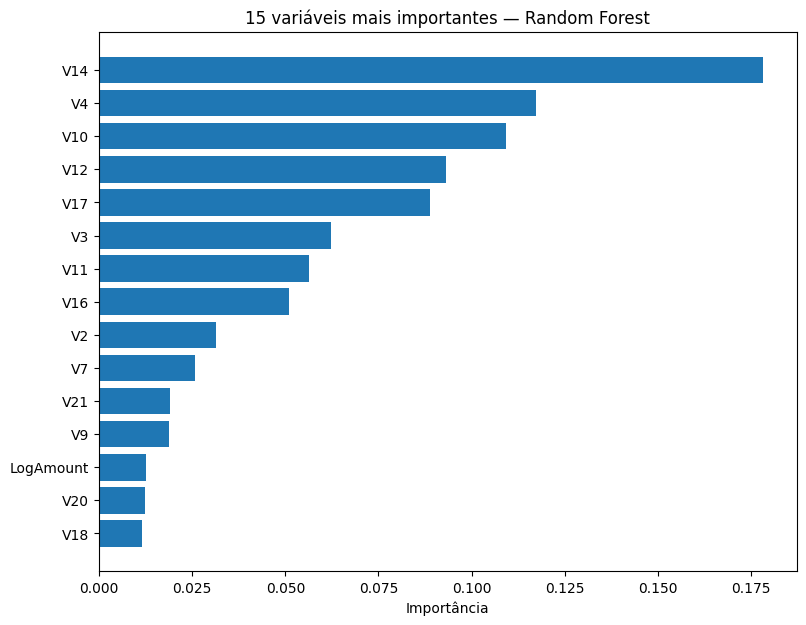

In [ ]:

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importância")
plt.title("15 variáveis mais importantes — Random Forest")
plt.show()


## 13. Explicabilidade com SHAP

In [ ]:

# Para o SHAP, usamos o XGBoost, que permite uma explicação baseada na estrutura
# de árvores do modelo.

xgb_model = trained_models["XGBoost"]

# O SHAP trabalha diretamente com o estimador XGBoost.
explainer = shap.TreeExplainer(xgb_model)

# Usamos uma amostra do teste para manter a visualização e o processamento leves.
X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=RANDOM_STATE
)

shap_values = explainer.shap_values(X_shap)


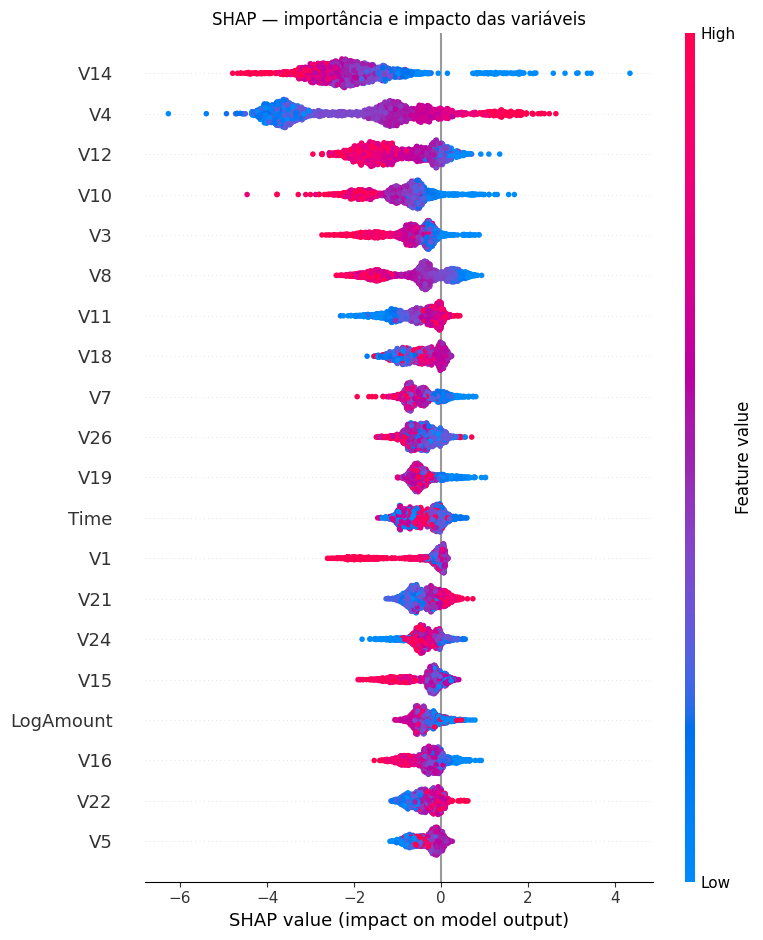

In [ ]:

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP — importância e impacto das variáveis")
plt.tight_layout()
plt.show()



### Como interpretar o gráfico SHAP

Cada ponto representa uma observação.

- Valores SHAP positivos empurram a previsão em direção à classe fraude;
- Valores SHAP negativos empurram a previsão em direção à classe normal;
- A posição horizontal representa o impacto da variável na decisão;
- A cor representa o valor da variável.

Assim, o SHAP ajuda a explicar não apenas **quais variáveis são importantes**, mas também **como elas contribuíram para as decisões do modelo**.


## 14. Explicando uma transação individual

In [ ]:

# Escolhemos uma transação que o modelo classificou como fraude
# usando o threshold selecionado.

test_probabilities = threshold_model.predict_proba(X_test)[:, 1]
fraud_candidates = np.where(test_probabilities >= best_threshold)[0]

if len(fraud_candidates) > 0:
    selected_position = fraud_candidates[0]
else:
    selected_position = np.argmax(test_probabilities)

selected_index = X_test.index[selected_position]
selected_transaction = X_test.loc[[selected_index]]

print("Índice da transação:", selected_index)
print("Probabilidade de fraude:", f"{test_probabilities[selected_position]:.4f}")
print("Classe real:", y_test.loc[selected_index])


Índice da transação: 190263
Probabilidade de fraude: 0.9763
Classe real: 0


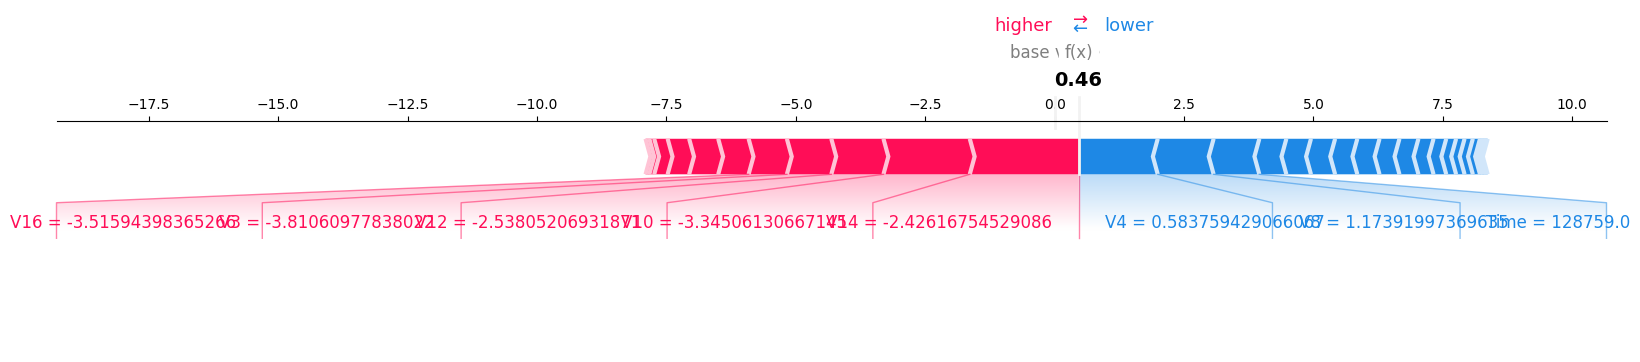

<Figure size 640x480 with 0 Axes>

In [ ]:

selected_shap = shap.TreeExplainer(
    threshold_model
).shap_values(selected_transaction)

shap.force_plot(
    shap.TreeExplainer(threshold_model).expected_value,
    selected_shap[0],
    selected_transaction.iloc[0],
    matplotlib=True
)

plt.tight_layout()
plt.show()


## 15. Comparação final

In [ ]:

final_comparison = results.copy()

final_comparison["Threshold utilizado"] = 0.50

final_comparison


,Modelo,Precision fraude,Recall fraude,F1 fraude,ROC-AUC,Average Precision,Threshold utilizado
0,Regressão Logística,0.060281,0.918367,0.113136,0.971117,0.711314,0.5
2,XGBoost,0.863158,0.836735,0.849741,0.979763,0.876461,0.5
1,Random Forest,0.961039,0.755102,0.845714,0.947063,0.859065,0.5



## Conclusão

A detecção de fraude é um problema em que a distribuição extremamente desigual entre as classes torna a acurácia uma métrica insuficiente.

Neste projeto foram comparados diferentes modelos utilizando principalmente Recall, Precision e F1 para a classe de fraude. Também foi analisado o efeito do limiar de decisão, mostrando que a mudança do threshold altera o equilíbrio entre fraudes detectadas e falsos positivos.

Além disso, foram testadas estratégias de undersampling e oversampling para tratar o desbalanceamento e utilizado SHAP para interpretar a contribuição das variáveis nas decisões do modelo.

### Próximos passos

- ampliar a busca de hiperparâmetros com `GridSearchCV`;
- testar outros modelos;
- criar variáveis comportamentais baseadas na sequência temporal das transações;
- testar outros thresholds;
- aprofundar a comparação entre técnicas de balanceamento.
